In [1]:
import torch
import os
import torch.nn.functional as F

# Directory containing .pt files
directory = '/export/c09/lavanya/languageIdentification/test_embedding_40'

# List all .pt files in the directory
pt_files = [f for f in os.listdir(directory) if f.endswith('.pt')]

/home/lshankar1/miniconda3/envs/capstone/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for pt_file in pt_files:
    file_path = os.path.join(directory, pt_file)
    data = torch.load(file_path)
    embeddings = data['embeddings']
    for i, audio_embedding in enumerate(embeddings):
        print(f"File: {pt_file}")
        print(f"Layer {i} embedding shape: {audio_embedding.shape}")
        print(f"shape of embedding first element: {audio_embedding.shape[0]}")
        print(f"shape of embedding second element: {audio_embedding.shape[1]}")

File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt
Layer 0 embedding shape: torch.Size([75, 1, 384])
shape of embedding first element: 75
shape of embedding second element: 1
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt
Layer 1 embedding shape: torch.Size([75, 1, 384])
shape of embedding first element: 75
shape of embedding second element: 1
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt
Layer 2 embedding shape: torch.Size([75, 1, 384])
shape of embedding first element: 75
shape of embedding second element: 1
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt
Layer 3 embedding shape: torch.Size([75, 1, 384])
shape of embedding first element: 75
shape of embedding second element: 1
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt
Layer 4 embedding shape: torch.Size([75, 1, 384])
shape of embed

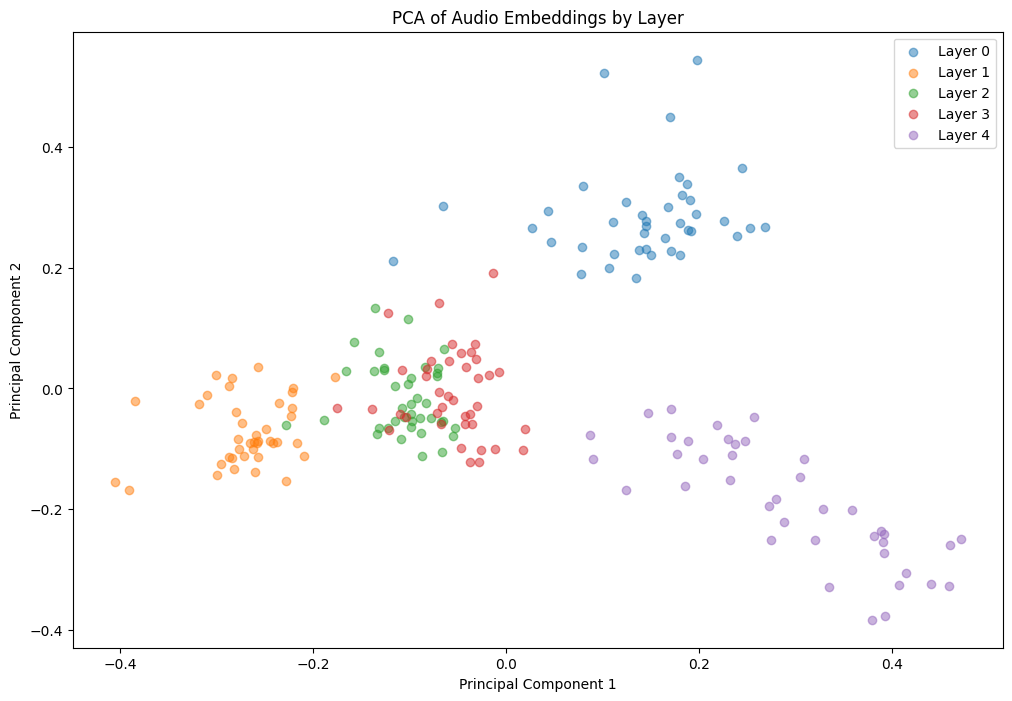

In [4]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Directory containing .pt files
directory = '/export/c09/lavanya/languageIdentification/test_embedding_40'

# List all .pt files in the directory
pt_files = [f for f in os.listdir(directory) if f.endswith('.pt')]

# Prepare lists to store embeddings and labels
all_embeddings = []
all_labels = []

# Define a fixed length for padding or truncating
fixed_length = 100  # Adjust this as needed based on your data

# Function to process each embedding
def process_embedding(embedding):
    # Flatten the embedding and pad or truncate to a fixed length
    flattened = embedding.flatten().numpy()
    if len(flattened) < fixed_length:
        # Pad with zeros if shorter than fixed length
        return np.pad(flattened, (0, fixed_length - len(flattened)), mode='constant')
    else:
        # Truncate if longer than fixed length
        return flattened[:fixed_length]

# Iterate over each file and layer
for pt_file in pt_files:
    file_path = os.path.join(directory, pt_file)
    data = torch.load(file_path)
    embeddings = data['embeddings']
    for i, audio_embedding in enumerate(embeddings):
        processed_embedding = process_embedding(audio_embedding)
        all_embeddings.append(processed_embedding)
        all_labels.append(i)  # Use the layer index as a label

# Convert list of arrays to a numpy array
all_embeddings = np.array(all_embeddings)
all_labels = np.array(all_labels)

# Perform PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Plot the PCA result
plt.figure(figsize=(12, 8))

# Create a scatter plot for each layer
for layer_index in range(5):
    indices = np.where(all_labels == layer_index)[0]
    plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], label=f'Layer {layer_index}', alpha=0.5)

plt.title('PCA of Audio Embeddings by Layer')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


In [24]:
max_len = 0

# First pass: Find the maximum length of all embeddings
for pt_file in pt_files:
    file_path = os.path.join(directory, pt_file)
    
    # Load the embeddings from the .pt file
    data = torch.load(file_path)
    
    if 'embeddings' in data:
        embeddings = data['embeddings']
        
        # Iterate over all embeddings and update the maximum length
        for audio_embedding in embeddings:
            max_len = max(max_len, audio_embedding.shape[0])  # Find max length along first dimension (time)
    else:
        print(f"No 'embeddings' key found in {pt_file}")

print(f"Maximum length of all embeddings: {max_len}")

Maximum length of all embeddings: 315


In [25]:
# Second pass: Pad all embeddings to the maximum length and reshape them
for pt_file in pt_files:
    file_path = os.path.join(directory, pt_file)
    
    # Load the embeddings from the .pt file
    data = torch.load(file_path)
    
    if 'embeddings' in data:
        embeddings = data['embeddings']
        reshaped_embeddings = []
        
        # Iterate over all embeddings, pad, and reshape them
        for i, audio_embedding in enumerate(embeddings):
            pad_size = max_len - audio_embedding.shape[0]  # Calculate padding required
            padded_embedding = F.pad(audio_embedding, (0, 0, 0, 0, 0, pad_size))  # Pad along the first dimension
            
            # Reshape the padded embedding from (315, 1, 384) to (1, 315, 384)
            reshaped_embedding = padded_embedding.permute(1, 0, 2)  # Change the dimensions
            reshaped_embeddings.append(reshaped_embedding)
            
            # Print the reshaped embedding shape
            print(f"File: {pt_file}, Layer {i} reshaped embedding shape: {reshaped_embedding.shape}")
        
        # Optionally, save the reshaped embeddings back to the file
        data['reshaped_embeddings'] = reshaped_embeddings
        torch.save(data, file_path)
    else:
        print(f"No 'embeddings' key found in {pt_file}")

File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt, Layer 0 reshaped embedding shape: torch.Size([1, 315, 384])
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt, Layer 1 reshaped embedding shape: torch.Size([1, 315, 384])
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt, Layer 2 reshaped embedding shape: torch.Size([1, 315, 384])
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt, Layer 3 reshaped embedding shape: torch.Size([1, 315, 384])
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt, Layer 4 reshaped embedding shape: torch.Size([1, 315, 384])
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_10.pt, Layer 0 reshaped embedding shape: torch.Size([1, 315, 384])
File: emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_10.pt, Layer 1 reshape

In [33]:
fi = '/export/c09/lavanya/languageIdentification/test_embedding_40/emb_TTS_P91182TT_VCST_ECxxx_01_AO_48503281_v001_R004_CRR_MERLIon-CCS_segment_0.pt'
data = torch.load(fi)
print(data.keys())
print(data['embeddings'][0].shape)
print(data['reshaped_embeddings'][0].shape)
print(data['padded_embeddings'][1].shape)
print("length of reshaped embeddings: ", len(data['reshaped_embeddings']))

dict_keys(['embeddings', 'padded_embeddings', 'reshaped_embeddings'])
torch.Size([75, 1, 384])
torch.Size([1, 315, 384])
torch.Size([315, 1, 384])
length of reshaped embeddings:  5
